# 前置作業：資料處理

In [1]:
import pandas as pd #處理表格資料
import numpy as np #處理線性代數、矩陣
import matplotlib.pyplot as plt #視覺化：畫圖

In [2]:
ratings = pd.read_csv(
    "data/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

ratings.head()
#讀取評分資料 u.data

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
movies = pd.read_csv(
    "data/u.item",
    sep="|",
    encoding="latin-1", #舊資料避免亂碼
    header=None,
    usecols=[0, 1], #只讀去 0 1 行
    names=["movie_id", "title"]
)

movies.head()
#讀取電影名稱 u.item

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [4]:
print("ratings shape:", ratings.shape)
print("movies shape:", movies.shape)

print("number of users:", ratings["user_id"].nunique())
print("number of movies:", ratings["movie_id"].nunique())
print("number of ratings:", len(ratings))
#確認資料大小

ratings shape: (100000, 4)
movies shape: (1682, 2)
number of users: 943
number of movies: 1682
number of ratings: 100000


In [5]:
R = ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
) #建立UserMovieMatrix

R.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
R.shape #檢查矩陣大小

(943, 1682)

In [7]:
total_entries = R.shape[0] * R.shape[1] #全部有多少筆資料
known_ratings = R.count().sum() #知道的資料
missing_entries = total_entries - known_ratings #空的資料

sparsity = missing_entries / total_entries #越小資料越稀疏

print("total entries:", total_entries)
print("known ratings:", known_ratings)
print("missing entries:", missing_entries)
print("sparsity:", sparsity)
#判斷資料有多稀疏

total entries: 1586126
known ratings: 100000
missing entries: 1486126
sparsity: 0.9369533063577546


In [8]:
R.head() #看到有很多空值，所以不能直接做SVD

movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
R_filled = R.apply(lambda row: row.fillna(row.mean()), axis=1)
#用每個User自己的評分的平均分補空值

R_filled.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.000000,3.000000,4.000000,3.000000,3.000000,5.000000,4.000000,1.000000,5.000000,3.000000,...,3.610294,3.610294,3.610294,3.610294,3.610294,3.610294,3.610294,3.610294,3.610294,3.610294
2,4.000000,3.709677,3.709677,3.709677,3.709677,3.709677,3.709677,3.709677,3.709677,2.000000,...,3.709677,3.709677,3.709677,3.709677,3.709677,3.709677,3.709677,3.709677,3.709677,3.709677
3,2.796296,2.796296,2.796296,2.796296,2.796296,2.796296,2.796296,2.796296,2.796296,2.796296,...,2.796296,2.796296,2.796296,2.796296,2.796296,2.796296,2.796296,2.796296,2.796296,2.796296
4,4.333333,4.333333,4.333333,4.333333,4.333333,4.333333,4.333333,4.333333,4.333333,4.333333,...,4.333333,4.333333,4.333333,4.333333,4.333333,4.333333,4.333333,4.333333,4.333333,4.333333
5,4.000000,3.000000,2.874286,2.874286,2.874286,2.874286,2.874286,2.874286,2.874286,2.874286,...,2.874286,2.874286,2.874286,2.874286,2.874286,2.874286,2.874286,2.874286,2.874286,2.874286


In [10]:
R_filled.isna().sum().sum() #確認還有沒有空值

np.int64(0)

In [11]:
R_matrix = R_filled.values #轉numpy矩陣

# 做SVD

In [12]:
#修正：在做SVD之前，先將每個User的評分中心化（減去平均分），這樣可以更好地捕捉用戶的偏好。
user_mean = R.mean(axis=1)

R_filled = R.apply(lambda row: row.fillna(row.mean()), axis=1)

R_centered = R_filled.sub(user_mean, axis=0)

R_centered_matrix = R_centered.values

In [13]:
U, s, Vt = np.linalg.svd(
    R_centered_matrix,
    full_matrices=False
)
# U：每個User在各個喜好特徵的權重
# s：最重要的特徵到最不重要的特徵
# V：每部電影具有的特徵
#R=UΣVT

In [14]:
print("U shape:", U.shape) 
print("s shape:", s.shape)
print("Vt shape:", Vt.shape)

U shape: (943, 943)
s shape: (943,)
Vt shape: (943, 1682)


In [15]:
s[:20]

array([81.8363891 , 50.4747599 , 38.78024093, 37.1754749 , 36.02449934,
       35.35606658, 33.46809535, 31.26180177, 29.62102925, 29.3751039 ,
       28.46053883, 28.03796107, 27.96399533, 27.60911726, 27.35750046,
       26.94052218, 26.83794322, 26.42970956, 26.34852204, 25.81111553])

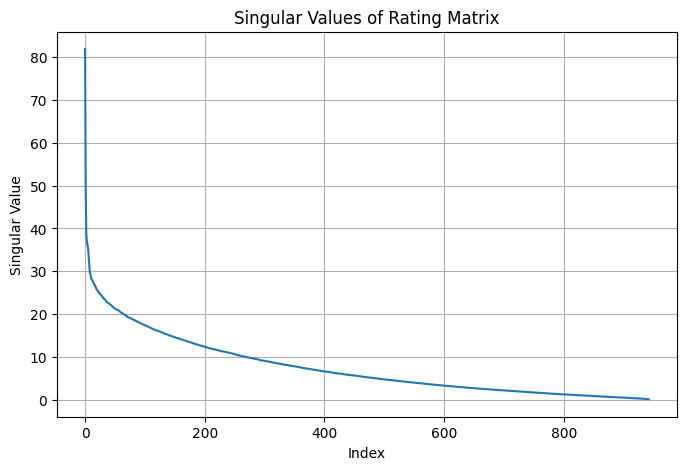

In [16]:
#畫出奇異值的分佈，看看前幾個特徵的重要程度
plt.figure(figsize=(8,5))

plt.plot(s)

plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.title("Singular Values of Rating Matrix")

plt.grid()
plt.show()

# Low Rank Aproximation

In [17]:
def reconstruct_matrix(U, s, Vt, k, user_mean):
    U_k = U[:, :k]
    s_k = np.diag(s[:k])
    Vt_k = Vt[:k, :]
    
    R_centered_hat = U_k @ s_k @ Vt_k
    #Rk​=Uk​Σk​VkT​
    
    R_hat = R_centered_hat + user_mean.values.reshape(-1, 1)
    
    return R_hat

In [18]:
#測試k=20
R_hat_20 = reconstruct_matrix(U, s, Vt, k=20, user_mean=user_mean)

R_hat_20.shape

(943, 1682)

# 估算RMSE

In [19]:
mask = ~R.isna().values
R_original = R.values

def rmse(R_original, R_pred, mask):
    return np.sqrt(np.mean((R_original[mask] - R_pred[mask]) ** 2))

In [20]:
rmse_20 = rmse(R_original, R_hat_20, mask)
rmse_20

np.float64(0.8493013727753496)

# 未訓練資料時，不同 k 值得重建矩陣與原矩陣有多像

In [21]:
k_values = [5, 10, 20, 50, 100]
rmse_values = []

for k in k_values:
    R_hat = reconstruct_matrix(U, s, Vt, k, user_mean)
    score = rmse(R_original, R_hat, mask)
    rmse_values.append(score)

result = pd.DataFrame({
    "k": k_values,
    "RMSE": rmse_values
})

result

,k,RMSE
0,5,0.937475
1,10,0.902651
2,20,0.849301
3,50,0.725291
4,100,0.574116


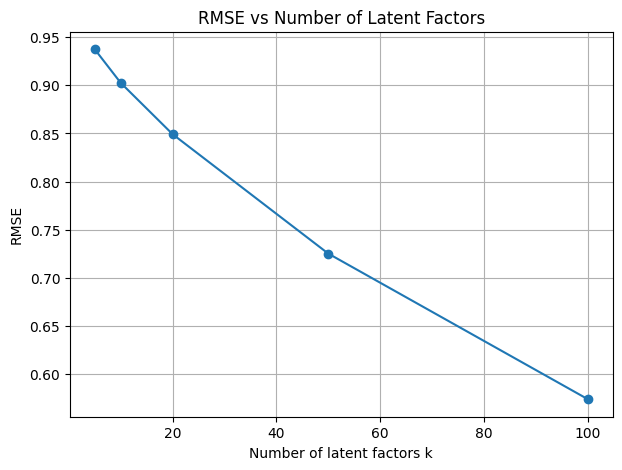

In [22]:
plt.figure(figsize=(7,5))

plt.plot(k_values, rmse_values, marker="o")

plt.xlabel("Number of latent factors k")
plt.ylabel("RMSE")
plt.title("RMSE vs Number of Latent Factors")

plt.grid()
plt.show()

# 開始訓練資料

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [25]:
train_df, test_df = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)
#將評分資料分成訓練集和測試集，80%訓練，20%測試

In [26]:
print(len(train_df))
print(len(test_df))

80000
20000


In [27]:
R_train = train_df.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)
#用train建立矩陣

In [28]:
user_mean = R_train.mean(axis=1)

R_filled = R_train.apply(
    lambda row: row.fillna(row.mean()),
    axis=1
)

R_centered = R_filled.sub(user_mean, axis=0)

R_centered_matrix = R_centered.values

#補空值、中心化、轉矩陣

# 對訓練資料做SVD

In [29]:
U, s, Vt = np.linalg.svd(
    R_centered_matrix,
    full_matrices=False
)

In [30]:
k = 10

R_hat = reconstruct_matrix(
    U,
    s,
    Vt,
    k,
    user_mean
)
#用訓練集的SVD結果重建矩陣，k=10

In [31]:
#評估在測試集上的表現，計算RMSE
user_to_index = {
    user: idx
    for idx, user in enumerate(R_train.index)
}

movie_to_index = {
    movie: idx
    for idx, movie in enumerate(R_train.columns)
}
predictions = []
actuals = []

In [32]:
#真正預測test集的評分，並與實際評分比較
for _, row in test_df.iterrows():
    
    user = row["user_id"]
    movie = row["movie_id"]
    actual = row["rating"]

    if (
        user in user_to_index
        and movie in movie_to_index
    ):

        u_idx = user_to_index[user]
        m_idx = movie_to_index[movie]

        pred = R_hat[u_idx, m_idx]

        predictions.append(pred)
        actuals.append(actual)

In [33]:
from sklearn.metrics import mean_squared_error

In [34]:
#計算RMSE
rmse_test = np.sqrt(
    mean_squared_error(
        actuals,
        predictions
    )
)

print(rmse_test)

0.9849135070175353


# 訓練後的資料不同 k 值的 RMSE

In [35]:
#測試不同k值對預測的影響
k_values = [5, 10, 20, 50, 100]

rmse_test_values = []

for k in k_values:

    R_hat = reconstruct_matrix(
        U,
        s,
        Vt,
        k,
        user_mean
    )

    predictions = []
    actuals = []

    for _, row in test_df.iterrows():

        user = row["user_id"]
        movie = row["movie_id"]
        actual = row["rating"]

        if (
            user in user_to_index
            and movie in movie_to_index
        ):

            u_idx = user_to_index[user]
            m_idx = movie_to_index[movie]

            pred = R_hat[u_idx, m_idx]

            predictions.append(pred)
            actuals.append(actual)

    rmse_test = np.sqrt(
        mean_squared_error(
            actuals,
            predictions
        )
    )

    rmse_test_values.append(rmse_test)

    print(f"k={k}, RMSE={rmse_test:.4f}")

k=5, RMSE=0.9911
k=10, RMSE=0.9849
k=20, RMSE=0.9877
k=50, RMSE=1.0018
k=100, RMSE=1.0184


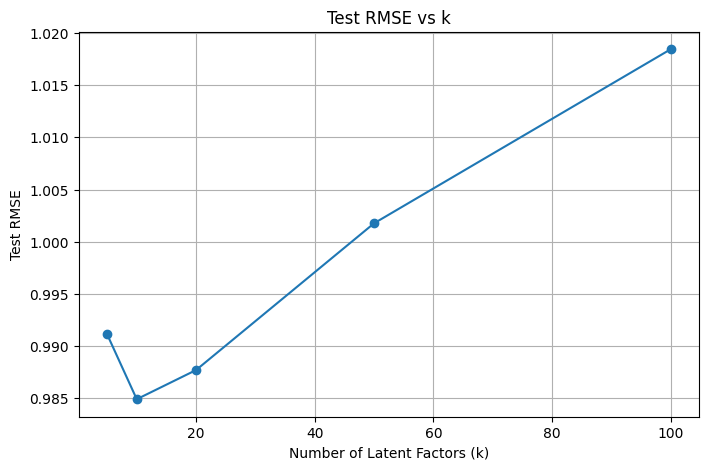

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    rmse_test_values,
    marker="o"
)

plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("Test RMSE")
plt.title("Test RMSE vs k")

plt.grid()
plt.show()

# 選最好的 k 值，產生推薦結果

In [37]:
best_k = 10

R_hat_best = reconstruct_matrix(
    U,
    s,
    Vt,
    best_k,
    user_mean
)

In [38]:
user_id = 1
watched_movies = R.loc[user_id].dropna().index
#推薦user_id=1沒有看過的電影，並且預測評分最高的前5部

In [39]:
user_idx = user_to_index[user_id]

predicted_ratings = pd.Series(
    R_hat_best[user_idx],
    index=R_train.columns
)
#取得預測評分，並轉成Series方便操作

In [40]:
recommendations = predicted_ratings.drop(watched_movies)
#使用者看過的電影不要重複推薦

In [41]:
top5 = recommendations.sort_values(
    ascending=False
).head(5)

top5
#推薦給user_id=1的前5部電影ID和預測評分

movie_id
474    4.444235
408    4.379337
511    4.194247
433    4.185096
302    4.159453
dtype: float64

In [42]:
movies.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [43]:
top5_movies = movies[
    movies["movie_id"].isin(top5.index)
][["movie_id", "title"]]

top5_movies
#推薦給User1的前五部電影名稱

,movie_id,title
301,302,L.A. Confidential (1997)
407,408,"Close Shave, A (1995)"
432,433,Heathers (1989)
473,474,Dr. Strangelove or: How I Learned to Stop Worr...
510,511,Lawrence of Arabia (1962)


In [44]:
user_id = 1

favorite_movies = (
    R.loc[user_id]
    .sort_values(ascending=False)
    .head(10)
)

favorite_movies
#User1最喜歡的前十部電影ID和評分

movie_id
270    5.0
1      5.0
269    5.0
268    5.0
6      5.0
228    5.0
221    5.0
223    5.0
224    5.0
202    5.0
Name: 1, dtype: float64

In [45]:
movies[
    movies["movie_id"].isin(favorite_movies.index)
][["movie_id","title"]]
#User1最喜歡的前十部電影名稱

,movie_id,title
0,1,Toy Story (1995)
5,6,Shanghai Triad (Yao a yao yao dao waipo qiao) ...
201,202,Groundhog Day (1993)
220,221,Breaking the Waves (1996)
222,223,Sling Blade (1996)
223,224,Ridicule (1996)
227,228,Star Trek: The Wrath of Khan (1982)
267,268,Chasing Amy (1997)
268,269,"Full Monty, The (1997)"
269,270,Gattaca (1997)


# 比較User1喜愛的和系統推薦的電影類型，確認推薦的結果好不好

In [46]:
#讀取MOVIE資料，包含GENRE
genre_cols = [
    "unknown", "Action", "Adventure", "Animation", "Children",
    "Comedy", "Crime", "Documentary", "Drama", "Fantasy",
    "Film-Noir", "Horror", "Musical", "Mystery", "Romance",
    "Sci-Fi", "Thriller", "War", "Western"
]

movie_cols = [
    "movie_id", "title", "release_date", "video_release_date",
    "IMDb_URL"
] + genre_cols

movies_full = pd.read_csv(
    "data/u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    names=movie_cols
)

movies_full.head()

,movie_id,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [47]:
#User1最喜歡的前十部電影名稱和類型
user_id = 1

favorite_movie_ids = (
    R.loc[user_id]
    .sort_values(ascending=False)
    .head(10)
    .index
)

favorite_movies = movies_full[
    movies_full["movie_id"].isin(favorite_movie_ids)
]

favorite_movies[["movie_id", "title"] + genre_cols]

,movie_id,title,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,6,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
201,202,Groundhog Day (1993),0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
220,221,Breaking the Waves (1996),0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
222,223,Sling Blade (1996),0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
223,224,Ridicule (1996),0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
227,228,Star Trek: The Wrath of Khan (1982),0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
267,268,Chasing Amy (1997),0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
268,269,"Full Monty, The (1997)",0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
269,270,Gattaca (1997),0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0


In [48]:
#取得推薦的五部電影
recommended_movie_ids = top5.index

recommended_movies = movies_full[
    movies_full["movie_id"].isin(recommended_movie_ids)
]

recommended_movies[["movie_id", "title"] + genre_cols]

,movie_id,title,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
301,302,L.A. Confidential (1997),0,0,0,0,0,0,1,0,...,0,1,0,0,1,0,0,1,0,0
407,408,"Close Shave, A (1995)",0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
432,433,Heathers (1989),0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
473,474,Dr. Strangelove or: How I Learned to Stop Worr...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
510,511,Lawrence of Arabia (1962),0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [49]:
#統計最推薦和最喜愛的電影分別的genre數量
favorite_genre_count = favorite_movies[genre_cols].sum()
recommended_genre_count = recommended_movies[genre_cols].sum()

genre_comparison = pd.DataFrame({
    "User Favorite Movies": favorite_genre_count,
    "Recommended Movies": recommended_genre_count
})

genre_comparison = genre_comparison[
    (genre_comparison["User Favorite Movies"] > 0) |
    (genre_comparison["Recommended Movies"] > 0)
]

genre_comparison

,User Favorite Movies,Recommended Movies
Action,1,0
Adventure,1,1
Animation,1,1
Children,1,0
Comedy,3,2
Crime,0,1
Drama,6,0
Film-Noir,0,1
Mystery,0,1
Romance,2,0


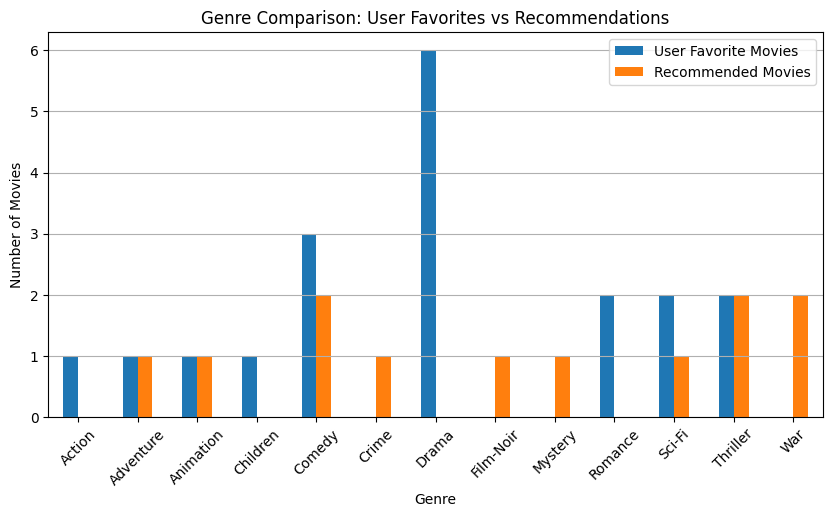

In [50]:
genre_comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.title("Genre Comparison: User Favorites vs Recommendations")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

# 預測User1會給系統推薦的前五部電影的評分

In [51]:
top5_df = pd.DataFrame({
    "movie_id": top5.index,
    "predicted_rating": top5.values
})

top5_df

,movie_id,predicted_rating
0,474,4.444235
1,408,4.379337
2,511,4.194247
3,433,4.185096
4,302,4.159453


In [52]:
top5_result = pd.merge(
    top5_df,
    movies_full[["movie_id", "title"]],
    on="movie_id"
)

top5_result

,movie_id,predicted_rating,title
0,474,4.444235,Dr. Strangelove or: How I Learned to Stop Worr...
1,408,4.379337,"Close Shave, A (1995)"
2,511,4.194247,Lawrence of Arabia (1962)
3,433,4.185096,Heathers (1989)
4,302,4.159453,L.A. Confidential (1997)


In [53]:
top5_result = top5_result.sort_values(
    by="predicted_rating",
    ascending=True
)

top5_result

,movie_id,predicted_rating,title
4,302,4.159453,L.A. Confidential (1997)
3,433,4.185096,Heathers (1989)
2,511,4.194247,Lawrence of Arabia (1962)
1,408,4.379337,"Close Shave, A (1995)"
0,474,4.444235,Dr. Strangelove or: How I Learned to Stop Worr...


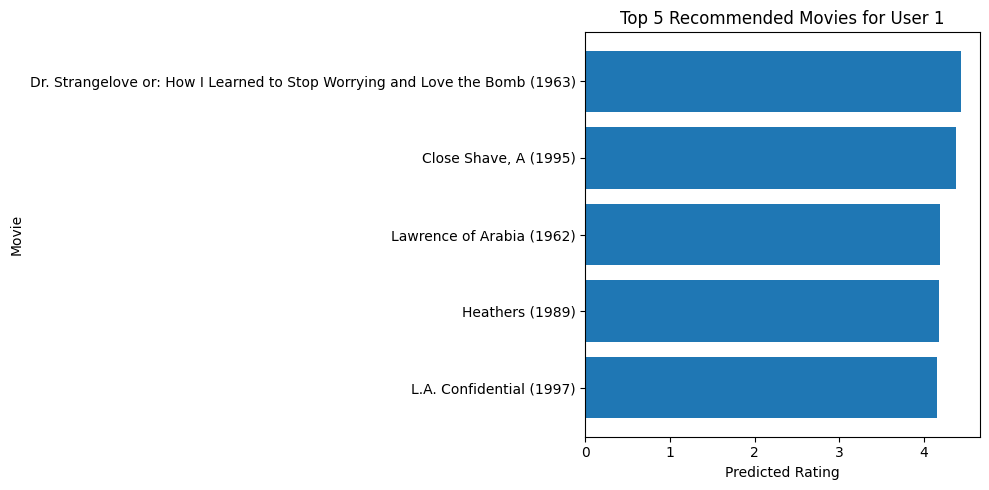

In [54]:
plt.figure(figsize=(10,5))

plt.barh(
    top5_result["title"],
    top5_result["predicted_rating"]
)

plt.xlabel("Predicted Rating")
plt.ylabel("Movie")
plt.title("Top 5 Recommended Movies for User 1")

plt.tight_layout()
plt.show()